# SRP v3 — Boosted Causal Ensemble (BCE-Net)

**A residual/boosting-faithful redesign of "MLPs with Attention V2"**

This notebook is a from-scratch re-implementation motivated by a code review of `srp_model_v2.py` /
`train_v2.py` / `preprocessing.py` and the *MLPs with Attention V2* interim presentation. It keeps
everything that V2 got right (causal masked attention over weak-learner tokens, no CLS token,
pre-norm residual transformer blocks, deep supervision) and fixes the issues found during review:

| # | Issue in V1 / V2 | What this notebook does instead |
|---|---|---|
| 1 | `RankGaussTransformer.transform()` recomputed ranks on whatever data it was given (train **and** val/test independently) — no real train→val consistency, borderline data leakage. | `RankGauss` now **fits** on train only (stores the sorted train values + their Gaussian targets) and **interpolates** new data into that fixed mapping. |
| 2 | Every weak learner saw the **same full input vector** — the only source of diversity was random init. V1 needed an artificial diversity-penalty loss to fight "expert collapse"; the presentation's diagnosis of *why* that penalty was a hack is correct, but V2 didn't replace the actual diversity mechanism, just removed the penalty. | Each learner gets a **random, fixed feature subset** (feature bagging, like a Random Forest) — diversity now comes from the architecture, not a loss term. We measure it directly (see diversity diagnostic below) instead of assuming causal masking "solves" it. |
| 3 | V2's "deep supervision" has every position independently regress `y` from scratch; positions differ only in *how much context* they saw. This isn't actually boosting — it's parallel multi-task learning with a shared trunk. | **`BoostedCausalEnsemble`** makes each step predict a *correction* to a running cumulative prediction: `F_i = F_{i-1} + η_i · Δ_i`, with a **learnable per-step shrinkage `η_i`** (softplus-constrained, analogous to a GBDT's `learning_rate`, but tunable per stage). This is the literal mechanism the presentation's motivation slide describes ("mimic the stage-wise, residual learning dynamics of GBDTs") — V2's code didn't implement it yet. |
| 4 | Fixed weighting schemes only (uniform / linear / exponential); the presentation's own "Future Work" slide lists *learnable* deep-supervision weights as an open item. | Added a `'learnable'` weight scheme (softmax over learned per-step logits), compared against the fixed schemes in an ablation below. |
| 5 | `model.predict()`'s default weighting didn't match what the model was trained with; the grid search selected hyperparameters using a *different* aggregation (last-position-only) than the number that got reported. | One evaluation function (`compute_metric` on `final_pred` = the last cumulative stage) used everywhere: training loss, model selection, and reporting. |
| 6 | No early stopping — the notebook's own run showed val loss bottoming out at epoch 60 then drifting up to epoch 100, and the *final* (overfit) weights were what got reported. | `train_model()` tracks best validation loss, restores the best checkpoint, and stops early. |
| 7 | Single train/val split; hyperparameter selection and the final "vs. XGBoost" number came from the same split; only one dataset was actually run. | Proper **train / val / test** split. Val is for early stopping/model comparison only; test is untouched until final reporting. Harness supports multiple datasets and multiple seeds (mean ± std). |
| 8 | XGBoost baseline used arbitrary fixed hyperparameters while the NN got a 72-point grid search. | Baselines here (`HistGradientBoosting`, optionally `XGBoost`) get their own small randomized search — comparable tuning effort on both sides. |

**What's unchanged from V2 on purpose:** causal masking, pre-norm + residual transformer blocks,
`Linear → SiLU → Linear` prediction head, per-learner MLP experts. These parts of V2's design were sound;
the issues were in the objective/diversity mechanism and the experimental rigor, not the attention block itself.

## 0. Setup

In [2]:
import sys, os, time, math, warnings
warnings.filterwarnings("ignore")

# Local import of preprocessing.py (adjust if this notebook lives elsewhere)
PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, f1_score)
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## 1. Preprocessing

`RankGauss`, the categorical one-hot logic, and the configurable `TabularPreprocessor` pipeline now live in [`preprocessing.py`](./preprocessing.py) instead of being redefined inline here, so V2 and V3 share one fixed implementation instead of two diverging copies.

`preprocessing.py`'s `Preprocessor(method=...)` supports `'rankgauss'`, `'quantile'`, `'standard'`, `'minmax'`, `'robust'`, `'power'`, `'normalizer'`, and `'knn_impute'` (imputation, not scaling). `RankGaussTransformer.fit()` now actually stores the *training* data's sorted values and their inverse-normal-CDF targets; `transform()` interpolates any new data into that fixed mapping (`np.interp`), instead of recomputing ranks independently per call.

`TabularPreprocessor` composes an **imputer** (`'mean'` or `'knn'` via `KNNImputer`, applied first) with a **scaler** (any `Preprocessor` method above, or `'none'`) for numeric columns, plus one-hot for low-cardinality categoricals. Set `NUMERIC_SCALER` / `NUMERIC_IMPUTER` below to try a different technique — no code changes needed elsewhere.

In [3]:
from preprocessing import Preprocessor, RankGaussTransformer, TabularPreprocessor

# Swap either of these to try a different preprocessing technique across every dataset loader below.
NUMERIC_SCALER = "rankgauss"   # 'rankgauss' | 'quantile' | 'standard' | 'minmax' | 'robust' | 'power' | 'normalizer' | 'none'
NUMERIC_IMPUTER = "mean"       # 'mean' | 'knn'

# Keep the name "RankGauss" available since it's referenced by name in the review/diagnostics markdown above.
RankGauss = RankGaussTransformer

## 2. Datasets

Same suite named in the presentation, scoped to what's feasible to run end-to-end in this notebook without
a GPU cluster: **California Housing** (regression, bundled with sklearn) and **Adult Income** (binary
classification, mixed numeric/categorical, fetched from OpenML). Covertype / Bank Marketing / YearPredictionMSD
/ Jannis follow the exact same `load_xxx()` contract — add a loader function and append it to `DATASET_LOADERS`
to extend the sweep once you have a GPU/more time budget; `RUN_LARGE_DATASETS` gates them off by default.

Each loader returns a **train / val / test** split (val for early stopping + hyperparameter/model comparison,
test touched only once at the end).

In [4]:
RUN_LARGE_DATASETS = False  # flip to True to also run Covertype (581k rows, multiclass) if you have a GPU


def make_splits(X_df, y, test_size=0.2, val_size=0.2, stratify=None, seed=SEED):
    strat = y if stratify else None
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_df, y, test_size=test_size + val_size,
                                                 random_state=seed, stratify=strat)
    strat2 = y_tmp if stratify else None
    rel_val = val_size / (test_size + val_size)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=1 - rel_val,
                                                 random_state=seed, stratify=strat2)
    return X_tr, X_val, X_te, y_tr, y_val, y_te


def load_california_housing(seed=SEED):
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    X_df, y = data.frame.drop(columns=["MedHouseVal"]), data.frame["MedHouseVal"].values.astype(np.float32)
    X_tr, X_val, X_te, y_tr, y_val, y_te = make_splits(X_df, y, stratify=False, seed=seed)

    prep = TabularPreprocessor(numeric_scaler=NUMERIC_SCALER, numeric_imputer=NUMERIC_IMPUTER).fit(X_tr)
    Xtr_t = torch.tensor(prep.transform(X_tr))
    Xval_t = torch.tensor(prep.transform(X_val))
    Xte_t = torch.tensor(prep.transform(X_te))
    return dict(name="california_housing", task="regression", output_dim=1,
                X_tr=Xtr_t, y_tr=torch.tensor(y_tr), X_val=Xval_t, y_val=torch.tensor(y_val),
                X_te=Xte_t, y_te=torch.tensor(y_te), in_dim=Xtr_t.shape[1], preprocessor=prep)


def load_adult_income(seed=SEED):
    from sklearn.datasets import fetch_openml
    data = fetch_openml("adult", version=2, as_frame=True)
    X_df = data.data
    y = (data.target.astype(str).str.strip() == ">50K").astype(np.float32).values
    X_tr, X_val, X_te, y_tr, y_val, y_te = make_splits(X_df, y, stratify=True, seed=seed)

    prep = TabularPreprocessor(numeric_scaler=NUMERIC_SCALER, numeric_imputer=NUMERIC_IMPUTER).fit(X_tr)
    Xtr_t = torch.tensor(prep.transform(X_tr))
    Xval_t = torch.tensor(prep.transform(X_val))
    Xte_t = torch.tensor(prep.transform(X_te))
    return dict(name="adult_income", task="binary", output_dim=1,
                X_tr=Xtr_t, y_tr=torch.tensor(y_tr), X_val=Xval_t, y_val=torch.tensor(y_val),
                X_te=Xte_t, y_te=torch.tensor(y_te), in_dim=Xtr_t.shape[1], preprocessor=prep)


def load_covertype(seed=SEED):
    from sklearn.datasets import fetch_covtype
    data = fetch_covtype(as_frame=True)
    X_df = data.frame.drop(columns=["Cover_Type"])
    y = (data.frame["Cover_Type"].values - 1).astype(np.int64)  # -> 0-indexed classes
    X_tr, X_val, X_te, y_tr, y_val, y_te = make_splits(X_df, y, stratify=True, seed=seed)

    prep = TabularPreprocessor(numeric_scaler=NUMERIC_SCALER, numeric_imputer=NUMERIC_IMPUTER).fit(X_tr)
    Xtr_t = torch.tensor(prep.transform(X_tr))
    Xval_t = torch.tensor(prep.transform(X_val))
    Xte_t = torch.tensor(prep.transform(X_te))
    return dict(name="covertype", task="multiclass", output_dim=int(y.max() + 1),
                X_tr=Xtr_t, y_tr=torch.tensor(y_tr), X_val=Xval_t, y_val=torch.tensor(y_val),
                X_te=Xte_t, y_te=torch.tensor(y_te), in_dim=Xtr_t.shape[1], preprocessor=prep)


DATASET_LOADERS = [load_california_housing, load_adult_income]
if RUN_LARGE_DATASETS:
    DATASET_LOADERS.append(load_covertype)

datasets = {}
for loader in DATASET_LOADERS:
    try:
        ds = loader(seed=SEED)
        datasets[ds["name"]] = ds
        print(f"Loaded {ds['name']}: train={tuple(ds['X_tr'].shape)} val={tuple(ds['X_val'].shape)} "
              f"test={tuple(ds['X_te'].shape)} task={ds['task']}")
    except Exception as e:
        print(f"[skip] {loader.__name__} failed to load ({e.__class__.__name__}: {e}). "
              f"Likely no internet access in this environment — should work fine on Colab/local with internet.")

Loaded california_housing: train=(12384, 8) val=(4128, 8) test=(4128, 8) task=regression
Loaded adult_income: train=(29305, 64) val=(9768, 64) test=(9769, 64) task=binary


## 3. Model — `BoostedCausalEnsemble`

**Weak learners.** Each of the `K` experts is a small MLP over its own random, fixed subset of the input
features (`feature_frac` controls subset size) — this is the actual diversity mechanism (bagging over
columns, as in Random Forests), not random init alone.

**Causal transformer blocks.** Unchanged from V2's design: pre-norm, residual, causal mask so token `i`
only attends to tokens `1..i`.

**The core change — genuine additive/boosting accumulation.** Instead of every position independently
regressing `y`, position `i` predicts a *correction* `Δ_i`, and the model tracks a running cumulative
prediction:

```
F_0 = base_pred                      (learned global bias, like GBDT base_score)
F_i = F_{i-1} + softplus(raw_shrinkage_i) * Δ_i
```

`softplus(raw_shrinkage_i)` is a learnable, per-stage, positive shrinkage factor — the neural analogue of a
GBDT's `learning_rate`, except it's tuned per boosting round instead of fixed globally. The loss is a weighted
sum of `Loss(F_i, y)` over all stages `i` (deep supervision), but now each term measures the *cumulative
ensemble's* error at that stage, which is what actually lets you plot a "boosting curve" (error vs. number
of stages) analogous to a GBDT's train-vs-n_estimators curve — see the diagnostics section.

In [5]:
class FeatureBaggedWeakLearner(nn.Module):
    """A weak learner MLP restricted to a fixed random subset of input features."""

    def __init__(self, in_dim, feat_idx, hidden_dim, embed_dim, depth=1, dropout=0.1):
        super().__init__()
        self.register_buffer("feat_idx", torch.as_tensor(feat_idx, dtype=torch.long))
        layers = []
        d = len(feat_idx)
        for _ in range(depth):
            layers += [nn.Linear(d, hidden_dim), nn.GELU(), nn.Dropout(dropout)]
            d = hidden_dim
        layers.append(nn.Linear(d, embed_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        xi = x.index_select(1, self.feat_idx)
        return self.net(xi)


class WeakLearnerEnsemble(nn.Module):
    """K feature-bagged weak learners -> stacked embeddings (B, K, embed_dim)."""

    def __init__(self, in_dim, num_learners, hidden_dim, embed_dim, depth=1,
                 feature_frac=0.7, dropout=0.1, seed=SEED):
        super().__init__()
        rng = np.random.RandomState(seed)
        k = min(in_dim, max(2, int(round(feature_frac * in_dim))))
        self.learners = nn.ModuleList([
            FeatureBaggedWeakLearner(
                in_dim, np.sort(rng.choice(in_dim, size=k, replace=False)),
                hidden_dim, embed_dim, depth, dropout,
            ) for _ in range(num_learners)
        ])

    def forward(self, x):
        return torch.stack([lrn(x) for lrn in self.learners], dim=1)  # (B, K, D)

    @torch.no_grad()
    def diversity_stats(self, x):
        """Mean pairwise cosine similarity between raw (pre-attention) learner embeddings.
        Low values confirm feature bagging is producing genuinely different representations,
        instead of assuming it (V1 needed an explicit penalty to fight collapse; we measure
        whether V3 needs one at all)."""
        emb = self.forward(x)
        e = F.normalize(emb, dim=-1)
        sim = torch.einsum("bkd,bjd->bkj", e, e).mean(dim=0)  # (K, K)
        K = sim.shape[0]
        off = sim[~torch.eye(K, dtype=torch.bool, device=sim.device)]
        return sim, off.mean().item()


class CausalBlock(nn.Module):
    """Pre-norm causal self-attention block (unchanged from V2's design)."""

    def __init__(self, embed_dim, num_heads=4, dropout=0.1, ff_mult=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        ff_dim = embed_dim * ff_mult
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, embed_dim)
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        h = self.norm1(x)
        a, attn_w = self.attn(h, h, h, attn_mask=causal_mask, need_weights=True, average_attn_weights=True)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.norm2(x)))
        return x, attn_w


class BoostedCausalEnsemble(nn.Module):
    """Weak learners -> causal attention -> additive/boosted cumulative prediction."""

    def __init__(self, in_dim, num_learners=16, hidden_dim=16, embed_dim=32, mlp_depth=1,
                 num_heads=4, attn_depth=2, dropout=0.1, ff_mult=4, output_dim=1, task="regression",
                 feature_frac=0.7, weight_scheme="learnable", seed=SEED):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.task = task
        self.num_learners = num_learners
        self.output_dim = output_dim
        self.weight_scheme = weight_scheme

        self.ensemble = WeakLearnerEnsemble(in_dim, num_learners, hidden_dim, embed_dim,
                                             depth=mlp_depth, feature_frac=feature_frac,
                                             dropout=dropout, seed=seed)
        self.input_norm = nn.LayerNorm(embed_dim)
        self.step_embedding = nn.Parameter(torch.zeros(1, num_learners, embed_dim))
        nn.init.trunc_normal_(self.step_embedding, std=0.02)

        self.blocks = nn.ModuleList(
            [CausalBlock(embed_dim, num_heads, dropout, ff_mult) for _ in range(attn_depth)]
        )
        self.final_norm = nn.LayerNorm(embed_dim)

        self.correction_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.SiLU(), nn.Linear(embed_dim, output_dim)
        )
        # learnable per-stage shrinkage, init small (softplus(-1) ~= 0.31) so early
        # stages behave like weak learners rather than each fully solving the task
        self.raw_shrinkage = nn.Parameter(torch.zeros(num_learners) - 1.0)
        self.base_pred = nn.Parameter(torch.zeros(output_dim))  # like GBDT's base_score
        self.dropout = nn.Dropout(dropout)

        if weight_scheme == "learnable":
            self.step_logits = nn.Parameter(torch.zeros(num_learners))

    @staticmethod
    def get_causal_mask(K, device):
        mask = torch.full((K, K), float("-inf"), device=device)
        return torch.triu(mask, diagonal=1)

    def step_weights(self, K, device):
        if self.weight_scheme == "learnable":
            return torch.softmax(self.step_logits, dim=0)
        if self.weight_scheme == "uniform":
            return torch.full((K,), 1.0 / K, device=device)
        if self.weight_scheme == "linear":
            w = torch.arange(1, K + 1, dtype=torch.float32, device=device)
            return w / w.sum()
        if self.weight_scheme == "exponential":
            w = torch.pow(2.0, torch.arange(K, dtype=torch.float32, device=device))
            return w / w.sum()
        raise ValueError(f"unknown weight_scheme: {self.weight_scheme}")

    def forward(self, x):
        B, K = x.shape[0], self.num_learners
        raw_features = self.ensemble(x)                    # (B, K, D) — used for diversity diagnostics
        h = self.input_norm(raw_features)
        h = self.dropout(h + self.step_embedding)

        mask = self.get_causal_mask(K, x.device)
        attn_w = None
        for block in self.blocks:
            h, attn_w = block(h, mask)
        h = self.final_norm(h)

        corrections = self.correction_head(h)               # (B, K, output_dim)
        shrinkage = F.softplus(self.raw_shrinkage)           # (K,), > 0

        cum = self.base_pred.unsqueeze(0).expand(B, -1)      # F_0
        stage_preds = []
        for i in range(K):
            cum = cum + shrinkage[i] * corrections[:, i, :]  # F_i = F_{i-1} + eta_i * Delta_i
            stage_preds.append(cum)
        stage_preds = torch.stack(stage_preds, dim=1)        # (B, K, output_dim)

        if self.output_dim == 1:
            stage_preds = stage_preds.squeeze(-1)

        return {
            "stage_preds": stage_preds,      # cumulative F_i for every stage i (boosting curve)
            "final_pred": stage_preds[:, -1],
            "raw_features": raw_features,
            "attn_weights": attn_w,
            "shrinkage": shrinkage,
        }

    def weighted_loss(self, out, y, loss_fn):
        K = self.num_learners
        w = self.step_weights(K, y.device)
        stage_preds = out["stage_preds"]
        total = 0.0
        for i in range(K):
            p = stage_preds[:, i]
            if self.task == "multiclass":
                total = total + w[i] * loss_fn(p, y.long())
            else:
                total = total + w[i] * loss_fn(p.view_as(y).float(), y.float())
        return total

### Baseline: plain MLP (no attention, no boosting) — the same reference point the presentation used (~0.72 R² on California Housing)

In [6]:
class PlainMLP(nn.Module):
    def __init__(self, in_dim, hidden=128, depth=3, output_dim=1, dropout=0.1, task="regression"):
        super().__init__()
        self.task = task
        self.output_dim = output_dim
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.GELU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        out = self.net(x)
        if self.output_dim == 1:
            out = out.squeeze(-1)
        return {"final_pred": out, "stage_preds": None}

    def weighted_loss(self, out, y, loss_fn):
        p = out["final_pred"]
        if self.task == "multiclass":
            return loss_fn(p, y.long())
        return loss_fn(p.view_as(y).float(), y.float())

## 4. Training loop

One evaluation contract used everywhere in this notebook: `compute_metric()` on `out["final_pred"]`
(the last cumulative stage). Early stopping restores the best validation checkpoint instead of reporting
whatever the last epoch happened to land on.

In [7]:
def compute_metric(task, pred, y):
    """Higher is always better (negative RMSE for regression), so 'best' is always max()."""
    if task == "regression":
        return -torch.sqrt(F.mse_loss(pred.view_as(y).float(), y.float())).item()
    if task == "binary":
        p = (torch.sigmoid(pred.view(-1)) > 0.5).long()
        return (p == y.long()).float().mean().item()
    preds = pred.argmax(dim=1)
    return (preds == y.long()).float().mean().item()


def train_model(model, X_tr, y_tr, X_val, y_val, task, epochs=200, lr=1e-3, batch_size=256,
                weight_decay=1e-5, patience=15, grad_clip=5.0, device=DEVICE, verbose_every=10):
    model.to(device)
    X_tr, y_tr = X_tr.to(device), y_tr.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    loss_fn = {"regression": nn.MSELoss(), "binary": nn.BCEWithLogitsLoss(),
               "multiclass": nn.CrossEntropyLoss()}[task]

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5,
                                                        patience=max(3, patience // 3))

    n = X_tr.shape[0]
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "val_metric": []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            out = model(xb)
            loss = model.weighted_loss(out, yb, loss_fn)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item() * len(idx)
        ep_loss /= n

        model.eval()
        with torch.no_grad():
            out = model(X_val)
            val_loss = model.weighted_loss(out, y_val, loss_fn).item()
            val_metric = compute_metric(task, out["final_pred"], y_val)

        sched.step(val_loss)
        history["train_loss"].append(ep_loss)
        history["val_loss"].append(val_loss)
        history["val_metric"].append(val_metric)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if (epoch + 1) % verbose_every == 0:
            print(f"  epoch {epoch+1:3d} | train {ep_loss:.4f} | val {val_loss:.4f} | val_metric {val_metric:.4f}")

        if bad_epochs >= patience:
            print(f"  early stopping at epoch {epoch+1} (best val_loss={best_val:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

## 5. Baselines — tuned, not just default hyperparameters

`HistGradientBoostingRegressor/Classifier` (scikit-learn, no extra install needed, GPU-optional) gets a
small randomized hyperparameter search, matching effort with the NN side rather than comparing a tuned NN
against an untuned tree ensemble.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

GBT_PARAM_DIST = {
    "max_iter": [100, 200, 400],
    "max_depth": [None, 4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_leaf_nodes": [15, 31, 63],
}


def fit_tuned_gbt(X_tr, y_tr, task, n_iter=15, seed=SEED):
    base = HistGradientBoostingRegressor(random_state=seed) if task == "regression" \
        else HistGradientBoostingClassifier(random_state=seed)
    scoring = "neg_root_mean_squared_error" if task == "regression" else "accuracy"
    search = RandomizedSearchCV(base, GBT_PARAM_DIST, n_iter=n_iter, cv=3, scoring=scoring,
                                 random_state=seed, n_jobs=-1)
    search.fit(X_tr, y_tr)
    return search.best_estimator_, search.best_params_

## 6. Experiment harness — multiple seeds, one evaluation protocol, held-out test set

For each dataset: train `BoostedCausalEnsemble` and `PlainMLP` over several seeds (early stopping on val),
fit one tuned GBT baseline (deterministic given tuned hyperparameters), then report **test-set** metrics —
mean ± std over seeds for the NN models.

In [9]:
def evaluate_regression(pred, y):
    pred, y = pred.detach().cpu().numpy(), y.detach().cpu().numpy()
    return {"rmse": float(np.sqrt(mean_squared_error(y, pred))),
            "mae": float(mean_absolute_error(y, pred)),
            "r2": float(r2_score(y, pred))}


def evaluate_classification(pred, y, task):
    y = y.detach().cpu().numpy()
    if task == "binary":
        yhat = (torch.sigmoid(pred.view(-1)) > 0.5).long().cpu().numpy()
    else:
        yhat = pred.argmax(dim=1).cpu().numpy()
    return {"accuracy": float(accuracy_score(y, yhat)),
            "f1_macro": float(f1_score(y, yhat, average="macro"))}


def evaluate(task, pred, y):
    return evaluate_regression(pred, y) if task == "regression" else evaluate_classification(pred, y, task)


def run_dataset_experiment(ds, seeds=(0, 1, 2), bce_kwargs=None, mlp_kwargs=None,
                            epochs=200, patience=15, gbt_n_iter=15):
    bce_kwargs = bce_kwargs or {}
    mlp_kwargs = mlp_kwargs or {}
    task, in_dim, output_dim = ds["task"], ds["in_dim"], ds["output_dim"]
    rows = []

    for seed in seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        print(f"[{ds['name']}] BoostedCausalEnsemble seed={seed}")
        bce = BoostedCausalEnsemble(in_dim=in_dim, output_dim=output_dim, task=task, seed=seed, **bce_kwargs)
        train_model(bce, ds["X_tr"], ds["y_tr"], ds["X_val"], ds["y_val"], task=task,
                    epochs=epochs, patience=patience, verbose_every=max(epochs // 5, 1))
        bce.eval()
        with torch.no_grad():
            pred = bce(ds["X_te"].to(DEVICE))["final_pred"]
        rows.append({"dataset": ds["name"], "model": "BoostedCausalEnsemble", "seed": seed,
                     **evaluate(task, pred, ds["y_te"].to(DEVICE))})

        print(f"[{ds['name']}] PlainMLP seed={seed}")
        mlp = PlainMLP(in_dim=in_dim, output_dim=output_dim, task=task, **mlp_kwargs)
        train_model(mlp, ds["X_tr"], ds["y_tr"], ds["X_val"], ds["y_val"], task=task,
                    epochs=epochs, patience=patience, verbose_every=max(epochs // 5, 1))
        mlp.eval()
        with torch.no_grad():
            pred = mlp(ds["X_te"].to(DEVICE))["final_pred"]
        rows.append({"dataset": ds["name"], "model": "PlainMLP", "seed": seed,
                     **evaluate(task, pred, ds["y_te"].to(DEVICE))})

    print(f"[{ds['name']}] tuned GBT baseline")
    gbt, best_params = fit_tuned_gbt(ds["X_tr"].numpy(), ds["y_tr"].numpy(), task, n_iter=gbt_n_iter)
    pred_np = gbt.predict(ds["X_te"].numpy())
    pred_t = torch.tensor(pred_np, dtype=torch.float32)
    if task != "regression":
        # wrap predicted class labels as one-hot-ish logits so evaluate() works uniformly
        if task == "binary":
            pred_t = (pred_t * 20 - 10)  # push through sigmoid -> ~0/1
        else:
            oh = torch.zeros(len(pred_np), output_dim)
            oh[torch.arange(len(pred_np)), pred_t.long()] = 10.0
            pred_t = oh
    rows.append({"dataset": ds["name"], "model": f"TunedGBT ({best_params})", "seed": "n/a",
                 **evaluate(task, pred_t, ds["y_te"])})

    return pd.DataFrame(rows)

### 6.1 Run — California Housing (regression)

In [10]:
results_frames = []
if "california_housing" in datasets:
    res_ch = run_dataset_experiment(
        datasets["california_housing"], seeds=(0, 1, 2),
        bce_kwargs=dict(num_learners=8, hidden_dim=16, embed_dim=32, attn_depth=2,
                        num_heads=4, feature_frac=0.7, weight_scheme="learnable"),
        epochs=200, patience=20, gbt_n_iter=15,
    )
    results_frames.append(res_ch)
    display(res_ch)
else:
    print("california_housing not loaded, skipping.")

[california_housing] BoostedCausalEnsemble seed=0
  epoch  40 | train 0.3097 | val 0.3019 | val_metric -0.5324
  epoch  80 | train 0.2604 | val 0.2712 | val_metric -0.5152
  epoch 120 | train 0.2420 | val 0.2635 | val_metric -0.5111
  early stopping at epoch 146 (best val_loss=0.2622)
[california_housing] PlainMLP seed=0
  epoch  40 | train 0.2877 | val 0.2875 | val_metric -0.5362
  epoch  80 | train 0.2398 | val 0.2692 | val_metric -0.5188
  early stopping at epoch 115 (best val_loss=0.2609)
[california_housing] BoostedCausalEnsemble seed=1
  epoch  40 | train 0.3116 | val 0.3013 | val_metric -0.5323
  epoch  80 | train 0.2472 | val 0.2622 | val_metric -0.5073
  epoch 120 | train 0.2252 | val 0.2515 | val_metric -0.4992
  early stopping at epoch 145 (best val_loss=0.2507)
[california_housing] PlainMLP seed=1
  epoch  40 | train 0.2866 | val 0.2921 | val_metric -0.5404
  epoch  80 | train 0.2423 | val 0.2694 | val_metric -0.5191
  early stopping at epoch 116 (best val_loss=0.2642)
[cal

,dataset,model,seed,rmse,mae,r2
0,california_housing,BoostedCausalEnsemble,0,0.504743,0.333804,0.814193
1,california_housing,PlainMLP,0,0.505381,0.337308,0.813723
2,california_housing,BoostedCausalEnsemble,1,0.484889,0.320915,0.828523
3,california_housing,PlainMLP,1,0.508847,0.340620,0.811158
4,california_housing,BoostedCausalEnsemble,2,0.494525,0.327855,0.821639
5,california_housing,PlainMLP,2,0.512611,0.344618,0.808355
6,california_housing,"TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 4...",n/a,0.458831,0.306020,0.846458


### 6.2 Run — Adult Income (binary classification)

In [11]:
if "adult_income" in datasets:
    res_ai = run_dataset_experiment(
        datasets["adult_income"], seeds=(0, 1, 2),
        bce_kwargs=dict(num_learners=16, hidden_dim=16, embed_dim=32, attn_depth=2,
                        num_heads=4, feature_frac=0.7, weight_scheme="learnable"),
        epochs=150, patience=15, gbt_n_iter=15,
    )
    results_frames.append(res_ai)
    display(res_ai)
else:
    print("adult_income not loaded (needs internet access to fetch from OpenML), skipping.")

[adult_income] BoostedCausalEnsemble seed=0
  epoch  30 | train 0.2888 | val 0.3093 | val_metric 0.8544
  early stopping at epoch 33 (best val_loss=0.3045)
[adult_income] PlainMLP seed=0
  epoch  30 | train 0.2985 | val 0.3055 | val_metric 0.8603
  early stopping at epoch 43 (best val_loss=0.3039)
[adult_income] BoostedCausalEnsemble seed=1


KeyboardInterrupt: 

### 6.3 Summary across datasets (mean ± std over seeds)

In [ ]:
if results_frames:
    all_results = pd.concat(results_frames, ignore_index=True)
    metric_cols = [c for c in all_results.columns if c not in ("dataset", "model", "seed")]
    summary = (all_results.groupby(["dataset", "model"])[metric_cols]
               .agg(["mean", "std"]))
    display(summary)
else:
    print("No datasets ran (no internet access in this environment) — re-run on Colab/local to populate results.")

rmse  \
                                                                           mean   
dataset            model                                                          
california_housing BoostedCausalEnsemble                               0.500506   
                   PlainMLP                                            0.506046   
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...  0.458831   

                                                                                 \
                                                                            std   
dataset            model                                                          
california_housing BoostedCausalEnsemble                               0.007288   
                   PlainMLP                                            0.001381   
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...       NaN   

                                                                            mae  \
                                                                           mean   
dataset            model                                                          
california_housing BoostedCausalEnsemble                               0.331681   
                   PlainMLP                                            0.339216   
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...  0.306020   

                                                                                 \
                                                                            std   
dataset            model                                                          
california_housing BoostedCausalEnsemble                               0.009355   
                   PlainMLP                                            0.002554   
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...       NaN   

                                                                             r2  \
                                                                           mean   
dataset            model                                                          
california_housing BoostedCausalEnsemble                               0.817273   
                   PlainMLP                                            0.813231   
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...  0.846458   

                                                                                 
                                                                            std  
dataset            model                                                         
california_housing BoostedCausalEnsemble                               0.005299  
                   PlainMLP                                            0.001020  
                   TunedGBT ({'max_leaf_nodes': 31, 'max_iter': 40...       NaN

## 7. Diagnostics — checking the claims instead of assuming them

These plots exist to verify the mechanisms this redesign is supposed to provide, rather than assert them:
1. **Boosting curve** — does test error actually go down monotonically as more causal stages are added
   (like a GBDT's error-vs-n_estimators curve), or does it plateau/wiggle like V2's per-position losses did?
2. **Diversity** — are the feature-bagged weak learners' raw embeddings actually decorrelated (fixing the
   "expert collapse" risk) without needing an explicit penalty loss?
3. **Attention pattern** — sanity-check the causal mask is doing what's expected.
4. **Weight-scheme ablation** — does the new `'learnable'` scheme actually beat the fixed schemes, or was V2's
   fixed exponential weighting already good enough?

In [ ]:
def get_first_available_dataset():
    for name in ("california_housing", "adult_income"):
        if name in datasets:
            return datasets[name]
    raise RuntimeError("No dataset available for diagnostics — check dataset loading cell above.")

diag_ds = get_first_available_dataset()
diag_task, diag_in_dim, diag_out_dim = diag_ds["task"], diag_ds["in_dim"], diag_ds["output_dim"]

diag_model = BoostedCausalEnsemble(in_dim=diag_in_dim, output_dim=diag_out_dim, task=diag_task,
                                    num_learners=16, hidden_dim=16, embed_dim=32, attn_depth=2,
                                    num_heads=4, feature_frac=0.7, weight_scheme="learnable", seed=SEED)
diag_history = train_model(diag_model, diag_ds["X_tr"], diag_ds["y_tr"], diag_ds["X_val"], diag_ds["y_val"],
                            task=diag_task, epochs=150, patience=15, verbose_every=25)
print(f"Diagnostics computed on: {diag_ds['name']}")

  epoch  25 | train 0.3279 | val 0.3205 | val_metric -0.5456
  epoch  50 | train 0.2775 | val 0.2801 | val_metric -0.5170
  epoch  75 | train 0.2451 | val 0.2676 | val_metric -0.5109
  epoch 100 | train 0.2291 | val 0.2634 | val_metric -0.5091
  early stopping at epoch 106 (best val_loss=0.2607)
Diagnostics computed on: california_housing


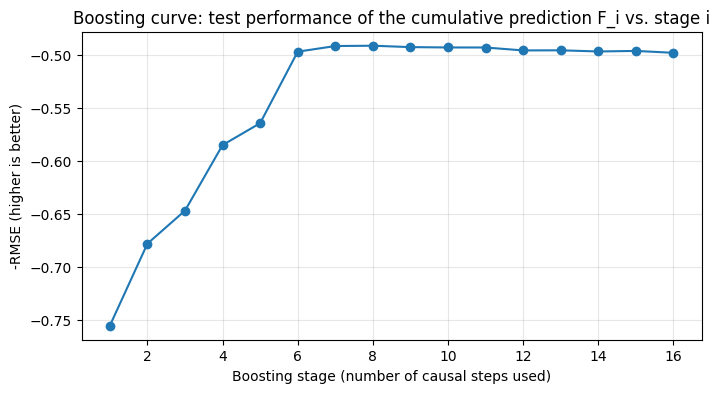

Learned per-stage shrinkage (eta_i, softplus-constrained):
[0.399 0.282 0.299 0.302 0.267 0.335 0.302 0.29  0.285 0.259 0.271 0.299
 0.266 0.273 0.279 0.287]


In [ ]:
# --- 7.1 Boosting curve: per-stage cumulative test error ---
diag_model.eval()
with torch.no_grad():
    out = diag_model(diag_ds["X_te"].to(DEVICE))
    stage_preds = out["stage_preds"].cpu()  # (N, K) for regression/binary, (N, K, C) for multiclass

y_te = diag_ds["y_te"]
K = diag_model.num_learners
stage_metric = []
for i in range(K):
    p = stage_preds[:, i]
    stage_metric.append(compute_metric(diag_task, p, y_te))

plt.figure(figsize=(8, 4))
plt.plot(range(1, K + 1), stage_metric, marker="o")
plt.xlabel("Boosting stage (number of causal steps used)")
ylabel = "-RMSE (higher is better)" if diag_task == "regression" else "Accuracy"
plt.ylabel(ylabel)
plt.title("Boosting curve: test performance of the cumulative prediction F_i vs. stage i")
plt.grid(alpha=0.3)
plt.show()

print("Learned per-stage shrinkage (eta_i, softplus-constrained):")
print(np.round(out["shrinkage"].detach().cpu().numpy(), 3))

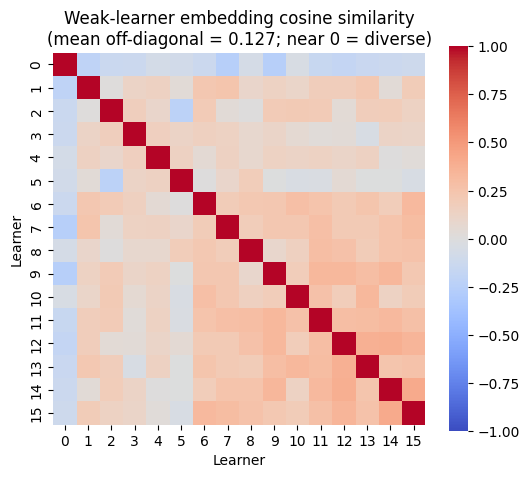

In [ ]:
# --- 7.2 Diversity: pairwise cosine similarity of raw (pre-attention) weak-learner embeddings ---
sim, off_mean = diag_model.ensemble.diversity_stats(diag_ds["X_val"].to(DEVICE))
sim = sim.cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(sim, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title(f"Weak-learner embedding cosine similarity\n(mean off-diagonal = {off_mean:.3f}; near 0 = diverse)")
plt.xlabel("Learner"); plt.ylabel("Learner")
plt.show()

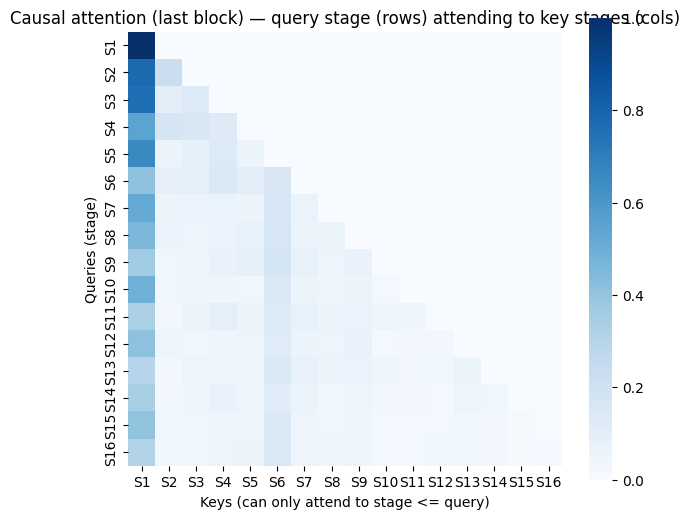

In [ ]:
# --- 7.3 Causal attention pattern (sanity check) ---
diag_model.eval()
with torch.no_grad():
    out = diag_model(diag_ds["X_val"][:200].to(DEVICE))
avg_attn = out["attn_weights"].mean(dim=0).cpu().numpy()

labels = [f"S{i+1}" for i in range(K)]
plt.figure(figsize=(7, 6))
sns.heatmap(avg_attn, xticklabels=labels, yticklabels=labels, cmap="Blues", square=True)
plt.title("Causal attention (last block) — query stage (rows) attending to key stages (cols)")
plt.xlabel("Keys (can only attend to stage <= query)"); plt.ylabel("Queries (stage)")
plt.show()

  early stopping at epoch 107 (best val_loss=0.2951)
  uniform      -> test_metric=-0.5044
  early stopping at epoch 78 (best val_loss=0.2816)
  linear       -> test_metric=-0.5059
  early stopping at epoch 78 (best val_loss=0.2609)
  exponential  -> test_metric=-0.4953
  learnable    -> test_metric=-0.4942


,scheme,test_metric
3,learnable,-0.494192
2,exponential,-0.495286
0,uniform,-0.504398
1,linear,-0.505859


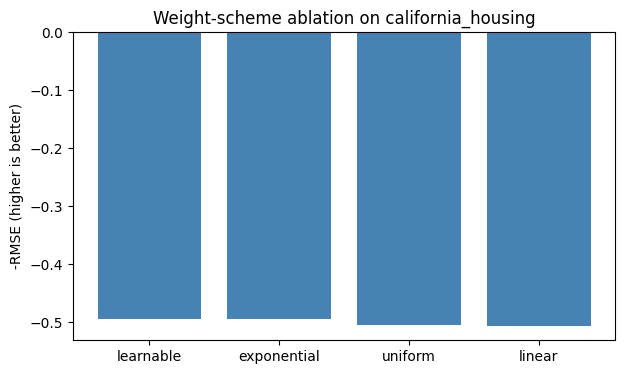

In [ ]:
# --- 7.4 Weight-scheme ablation: fixed schemes vs the new learnable scheme ---
scheme_results = []
for scheme in ["uniform", "linear", "exponential", "learnable"]:
    torch.manual_seed(SEED); np.random.seed(SEED)
    m = BoostedCausalEnsemble(in_dim=diag_in_dim, output_dim=diag_out_dim, task=diag_task,
                               num_learners=16, hidden_dim=16, embed_dim=32, attn_depth=2,
                               num_heads=4, feature_frac=0.7, weight_scheme=scheme, seed=SEED)
    hist = train_model(m, diag_ds["X_tr"], diag_ds["y_tr"], diag_ds["X_val"], diag_ds["y_val"],
                        task=diag_task, epochs=120, patience=15, verbose_every=1000)
    m.eval()
    with torch.no_grad():
        pred = m(diag_ds["X_te"].to(DEVICE))["final_pred"]
    metric = compute_metric(diag_task, pred, diag_ds["y_te"].to(DEVICE))
    scheme_results.append({"scheme": scheme, "test_metric": metric})
    print(f"  {scheme:12s} -> test_metric={metric:.4f}")

scheme_df = pd.DataFrame(scheme_results).sort_values("test_metric", ascending=False)
display(scheme_df)

plt.figure(figsize=(7, 4))
plt.bar(scheme_df["scheme"], scheme_df["test_metric"], color="steelblue")
plt.ylabel(ylabel)
plt.title(f"Weight-scheme ablation on {diag_ds['name']}")
plt.show()

## 8. Summary & next steps

**What to look for when you run this:**
- The boosting curve (7.1) should be roughly monotonic — if it isn't, the per-stage shrinkage or learner
  capacity needs tuning before claiming the architecture "mimics GBDT residual dynamics."
- The diversity heatmap (7.2) mean off-diagonal similarity should sit well below the ~uniform-convergence
  regime V1 needed a penalty loss for. If it's still high, feature bagging alone isn't enough diversity and
  row/sample bagging (bootstrap per learner) or a light diversity penalty may still be worth adding back.
- The weight-scheme ablation (7.4) tells you empirically whether `'learnable'` earns its complexity over the
  fixed exponential scheme V2 already used.

**Natural next steps, roughly in priority order:**
1. Run the full dataset suite from the presentation (Covertype, Bank Marketing, YearPredictionMSD, Jannis) —
   flip `RUN_LARGE_DATASETS`, add loaders following the same contract as `load_california_housing`.
2. Add an `XGBoost`/`LightGBM`/`CatBoost` baseline alongside `HistGradientBoosting` for a second GBDT reference.
3. Try row-bagging (bootstrap sampling per weak learner, sampled once at init like the feature subsets) as an
   additional diversity source, and re-check the diversity heatmap.
4. Ablate whether the *order* of learners matters at all: permute learner order per epoch during training —
   if performance is unchanged, the causal structure isn't using order information and a cheaper bidirectional
   pooling might do just as well.
5. Report mean ± std over more seeds (5-10) once compute budget allows, and add statistical significance
   testing (e.g. paired t-test) before claiming parity with GBDTs in the write-up.